In [1]:
# Step 01: Load the Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/raw/train.csv', parse_dates=['date'])
print(f"Original shape: {df.shape}")
print(df.head(3))

Original shape: (913000, 4)
        date  store  item  sales
0 2013-01-01      1     1     13
1 2013-01-02      1     1     11
2 2013-01-03      1     1     14


In [3]:
# Step 02: Feature Engineering

In [4]:
def engineer_features(df):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values(['store', 'item', 'date']).reset_index(drop=True)
    
    # Calendar features
    df['year']         = df['date'].dt.year
    df['month']        = df['date'].dt.month
    df['day']          = df['date'].dt.day
    df['day_of_week']  = df['date'].dt.dayofweek
    df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
    df['quarter']      = df['date'].dt.quarter
    df['is_weekend']   = (df['day_of_week'] >= 5).astype(int)
    df['is_month_start'] = df['date'].dt.is_month_start.astype(int)
    df['is_month_end']   = df['date'].dt.is_month_end.astype(int)
    
    # Lag features — what sold N days ago?
    for lag in [7, 14, 21, 28, 90, 180, 365]:
        df[f'lag_{lag}'] = df.groupby(['store', 'item'])['sales'].shift(lag)
    
    # Rolling window features — average/std over past N days
    for window in [7, 14, 30, 90]:
        df[f'rolling_mean_{window}'] = df.groupby(['store', 'item'])['sales'].transform(lambda x: x.shift(1).rolling(window).mean())
        df[f'rolling_std_{window}']  = df.groupby(['store', 'item'])['sales'].transform(lambda x: x.shift(1).rolling(window).std())
    
    # Exponentially weighted mean (recent data counts more)
    df['ewm_7'] = (
        df.groupby(['store', 'item'])['sales']
        .transform(lambda x: x.shift(1).ewm(span=7, min_periods=1).mean())
    )
    
    # Days since start (captures long-term growth trend)
    df['days_since_start'] = (df['date'] - df['date'].min()).dt.days
    
    return df

print("Function defined. Running feature engineering now...")
df_features = engineer_features(df)
df_features = df_features.dropna()   # Remove rows where lags are NaN
print(f"Shape after feature engineering: {df_features.shape}")
print(f"New features added: {df_features.shape[1] - 4}")

Function defined. Running feature engineering now...
Shape after feature engineering: (730500, 30)
New features added: 26


In [5]:
# Step 03: Saving the processed data

In [7]:
df_features.to_csv('../data/processed/features_engineered.csv', index=False)
print("Saved to data/processed/features_engineered.csv")
print("\nSample of new features:")
df_features[['date', 'store', 'item', 'sales', 'lag_7', 'lag_365', 'rolling_mean_30', 'is_weekend']].head(10)

Saved to data/processed/features_engineered.csv

Sample of new features:


,date,store,item,sales,lag_7,lag_365,rolling_mean_30,is_weekend
365,2014-01-01,1,1,9,6.0,13.0,12.400000,0
366,2014-01-02,1,1,14,16.0,11.0,12.433333,0
367,2014-01-03,1,1,11,18.0,14.0,12.200000,0
368,2014-01-04,1,1,20,17.0,13.0,12.366667,1
369,2014-01-05,1,1,17,14.0,10.0,12.600000,1
370,2014-01-06,1,1,14,5.0,12.0,12.666667,0
371,2014-01-07,1,1,11,15.0,10.0,12.566667,0
372,2014-01-08,1,1,12,9.0,9.0,12.366667,0
373,2014-01-09,1,1,17,14.0,12.0,12.500000,0
374,2014-01-10,1,1,12,11.0,9.0,12.600000,0


In [8]:
# Step 04: Visualizing a lag feature (to prove that it is actually working)

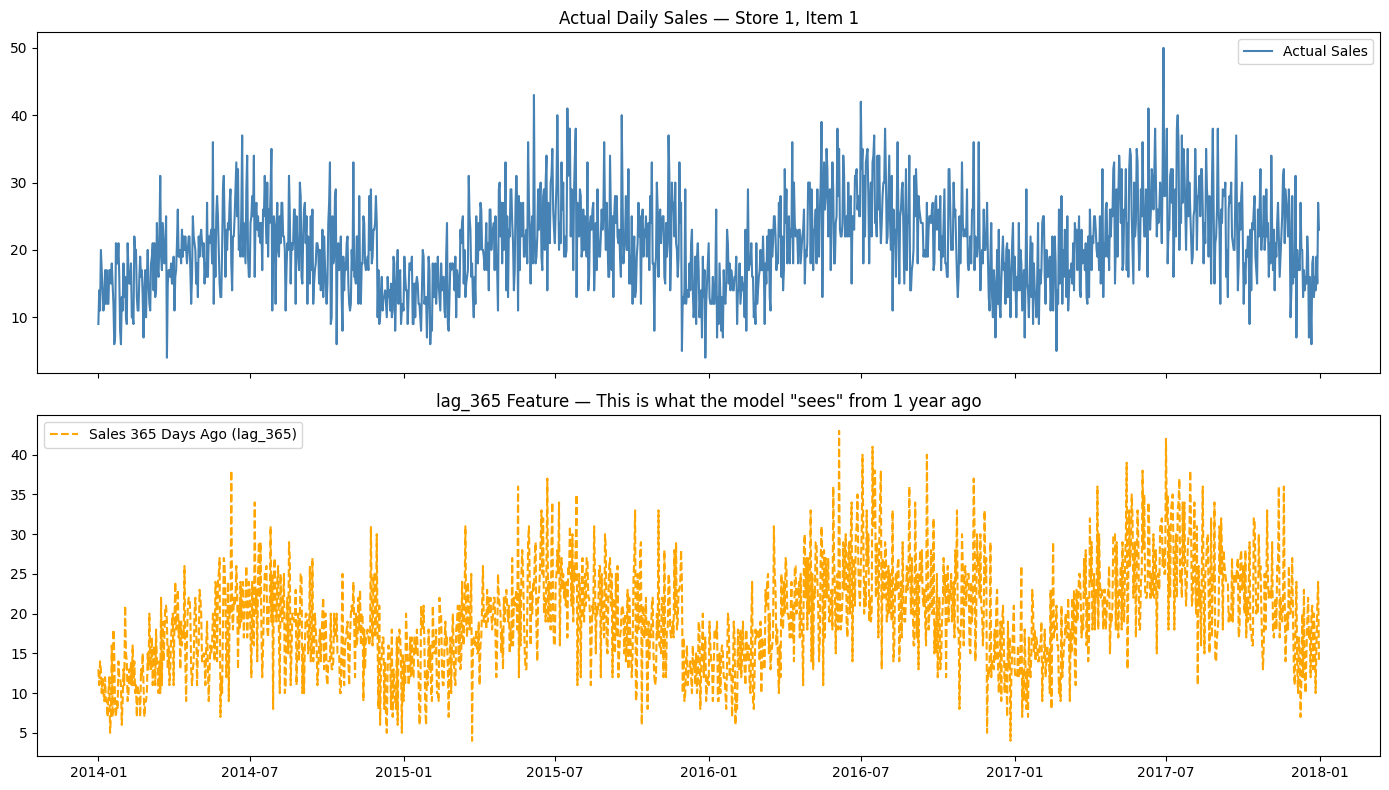

This shows WHY lag features work:- past sales mirror future sales.


In [9]:
# Show how lag_365 correlates with actual sales
sample = df_features[(df_features['store'] == 1) & (df_features['item'] == 1)]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(sample['date'], sample['sales'], label='Actual Sales', color='steelblue')
axes[0].set_title('Actual Daily Sales — Store 1, Item 1')
axes[0].legend()

axes[1].plot(sample['date'], sample['lag_365'], label='Sales 365 Days Ago (lag_365)', 
             color='orange', linestyle='--')
axes[1].set_title('lag_365 Feature — This is what the model "sees" from 1 year ago')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/lag_visualization.png', dpi=150)
plt.show()

print("This shows WHY lag features work:- past sales mirror future sales.")